# **Exploración de datos con Python**



Práctica de análisis exploratorio de datos utilizando estadística descriptiva, visualizaciones, correlaciones y detección de valores atípicos.

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importar datos

df_yout= pd.read_csv("/content/youtube_clean.csv")

df_yout

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [ ]:
# Ver resumen estadístico de las columnas numéricas

columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_yout[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

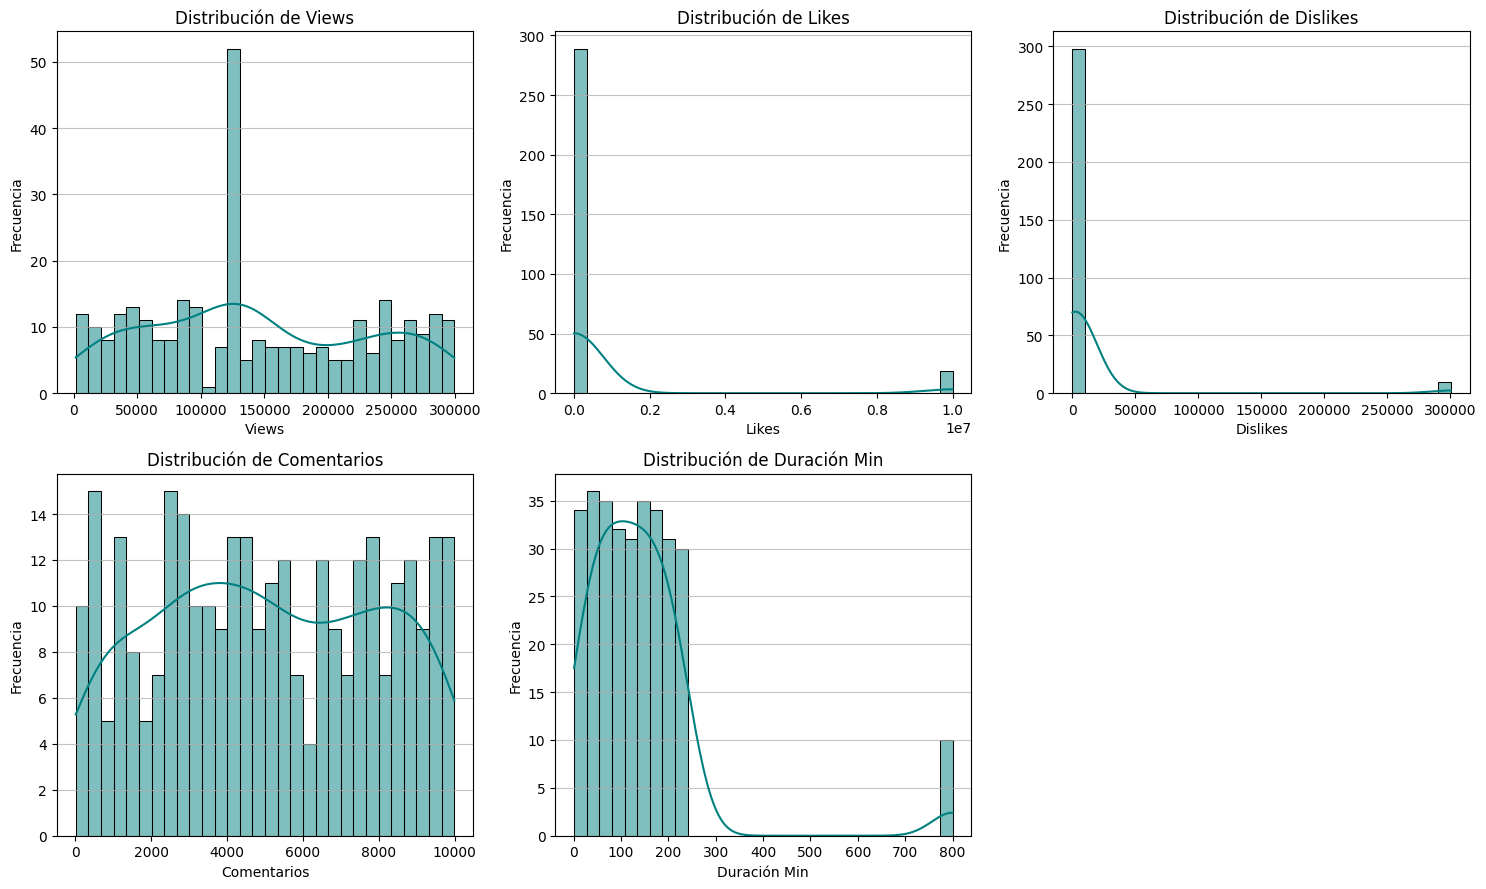

In [ ]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_yout[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

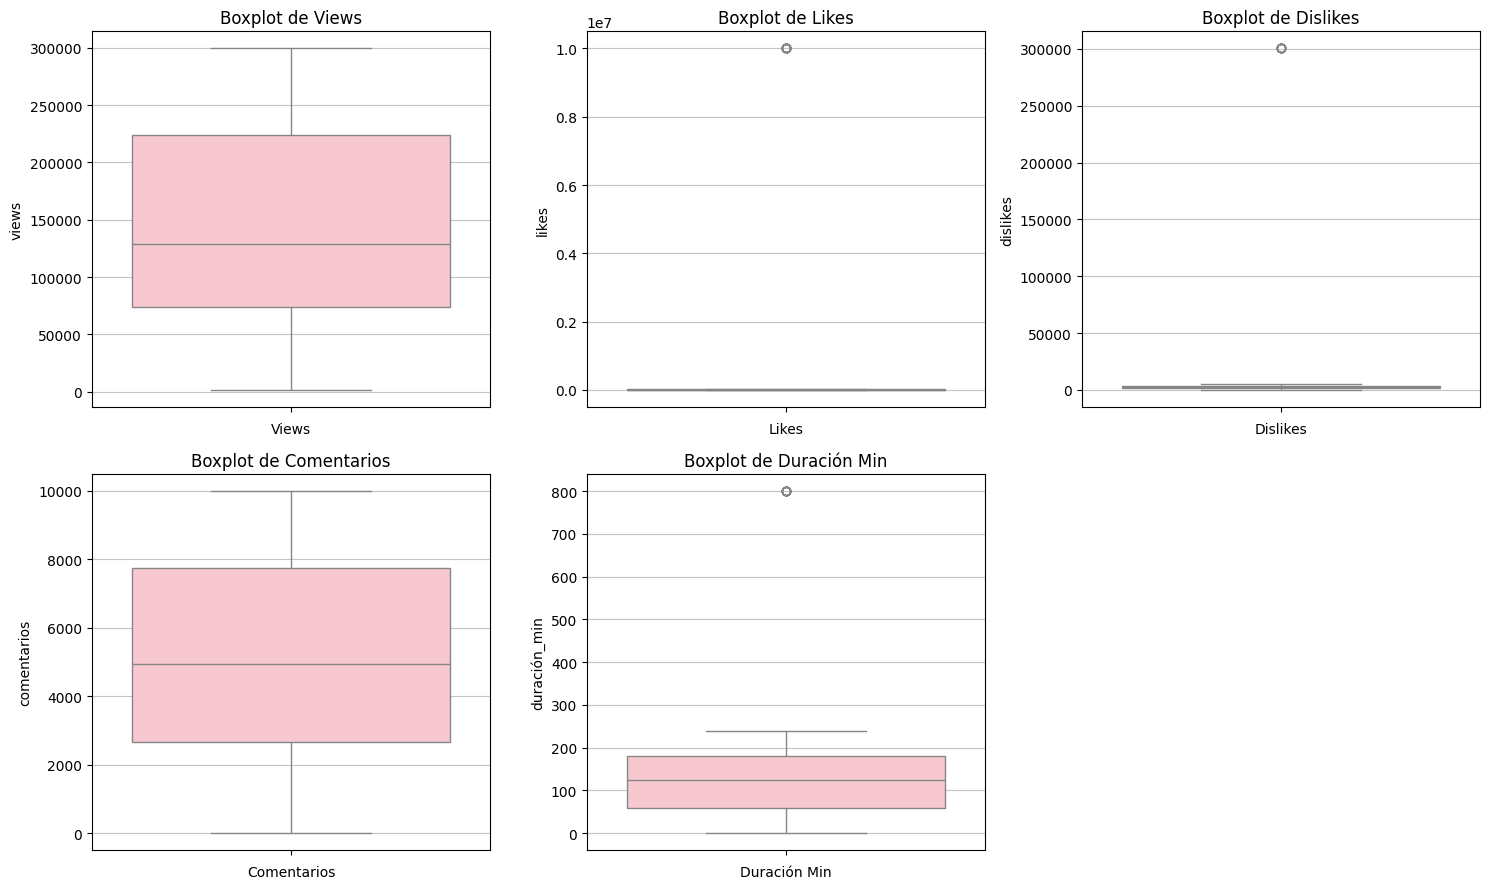

In [ ]:
# Observar comportamiento cuartil de los datos


plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_yout[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [ ]:
# Ver cantidad de registros iniciales

print(f'Cantidad de datos iniciales: {len(df_yout)}')

Cantidad de datos iniciales: 308


In [ ]:
# Calculo del IQR

df_copy = df_yout.copy() # Preservar el dataset haciendo una copia

for col in columnas_numericas:

  Q1 = df_copy[col].quantile(0.25) # Primer cuartil
  Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
  IQR = Q3 - Q1

  lim_inf_iqr = Q1 - 1.5 * IQR # Limite inferior
  lim_sup_iqr = Q3 + 1.5 * IQR # Limite superior

  cant_inicial = len(df_copy)

  # Filtro de los datos dentro de los limites
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)

  print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")

Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.
Columna 'duración_min': Se eliminaron 10 registros.


In [ ]:
# Ver cantidad de registros finales y proporción con la cantidad inicial\


print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Proporción de datos eliminados: {(len(df_yout) - len(df_copy)) / len(df_yout) * 100:.2f}%')

Cantidad de datos finales: 269
Proporción de datos eliminados: 12.66%


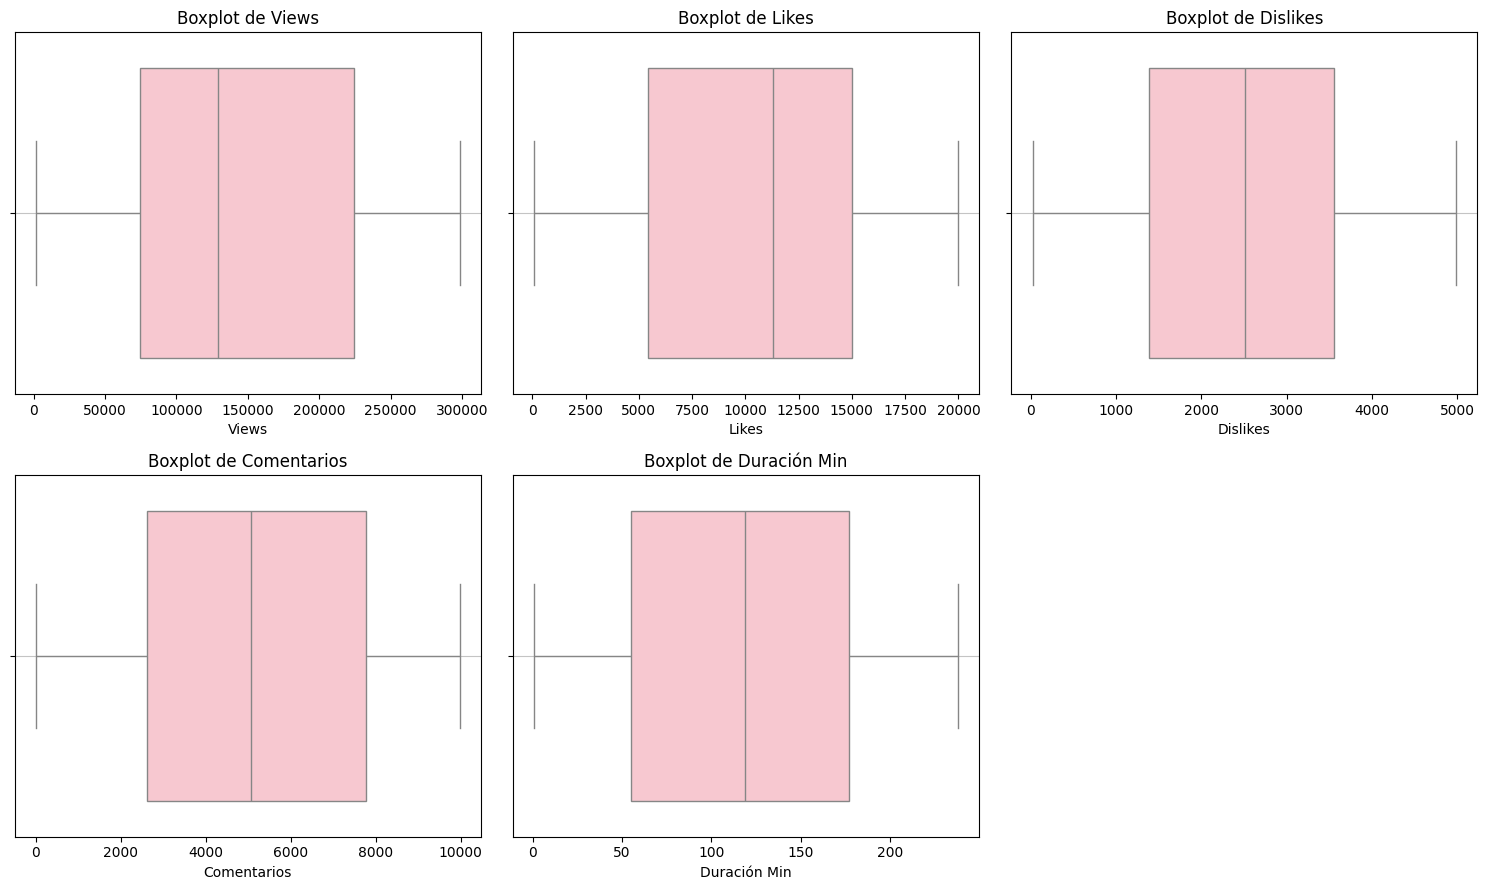

In [ ]:
# Observar comportamiento cuartil final de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

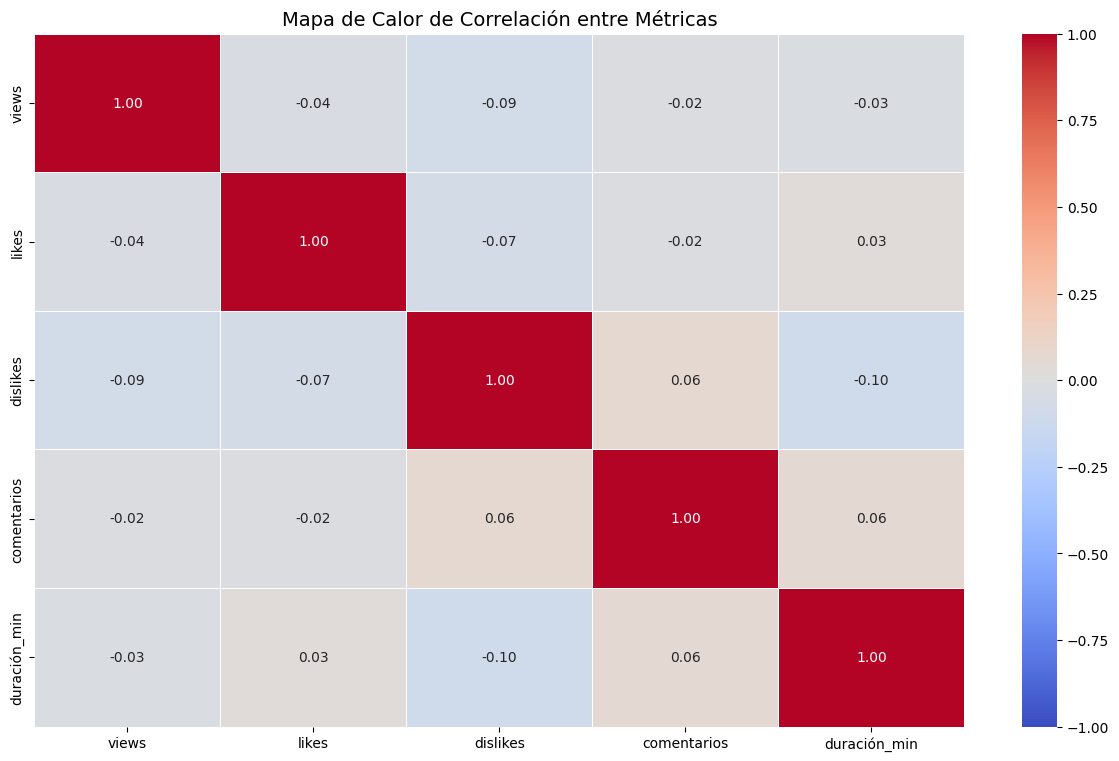

In [ ]:
# Realizar matriz de correlación

corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(15, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

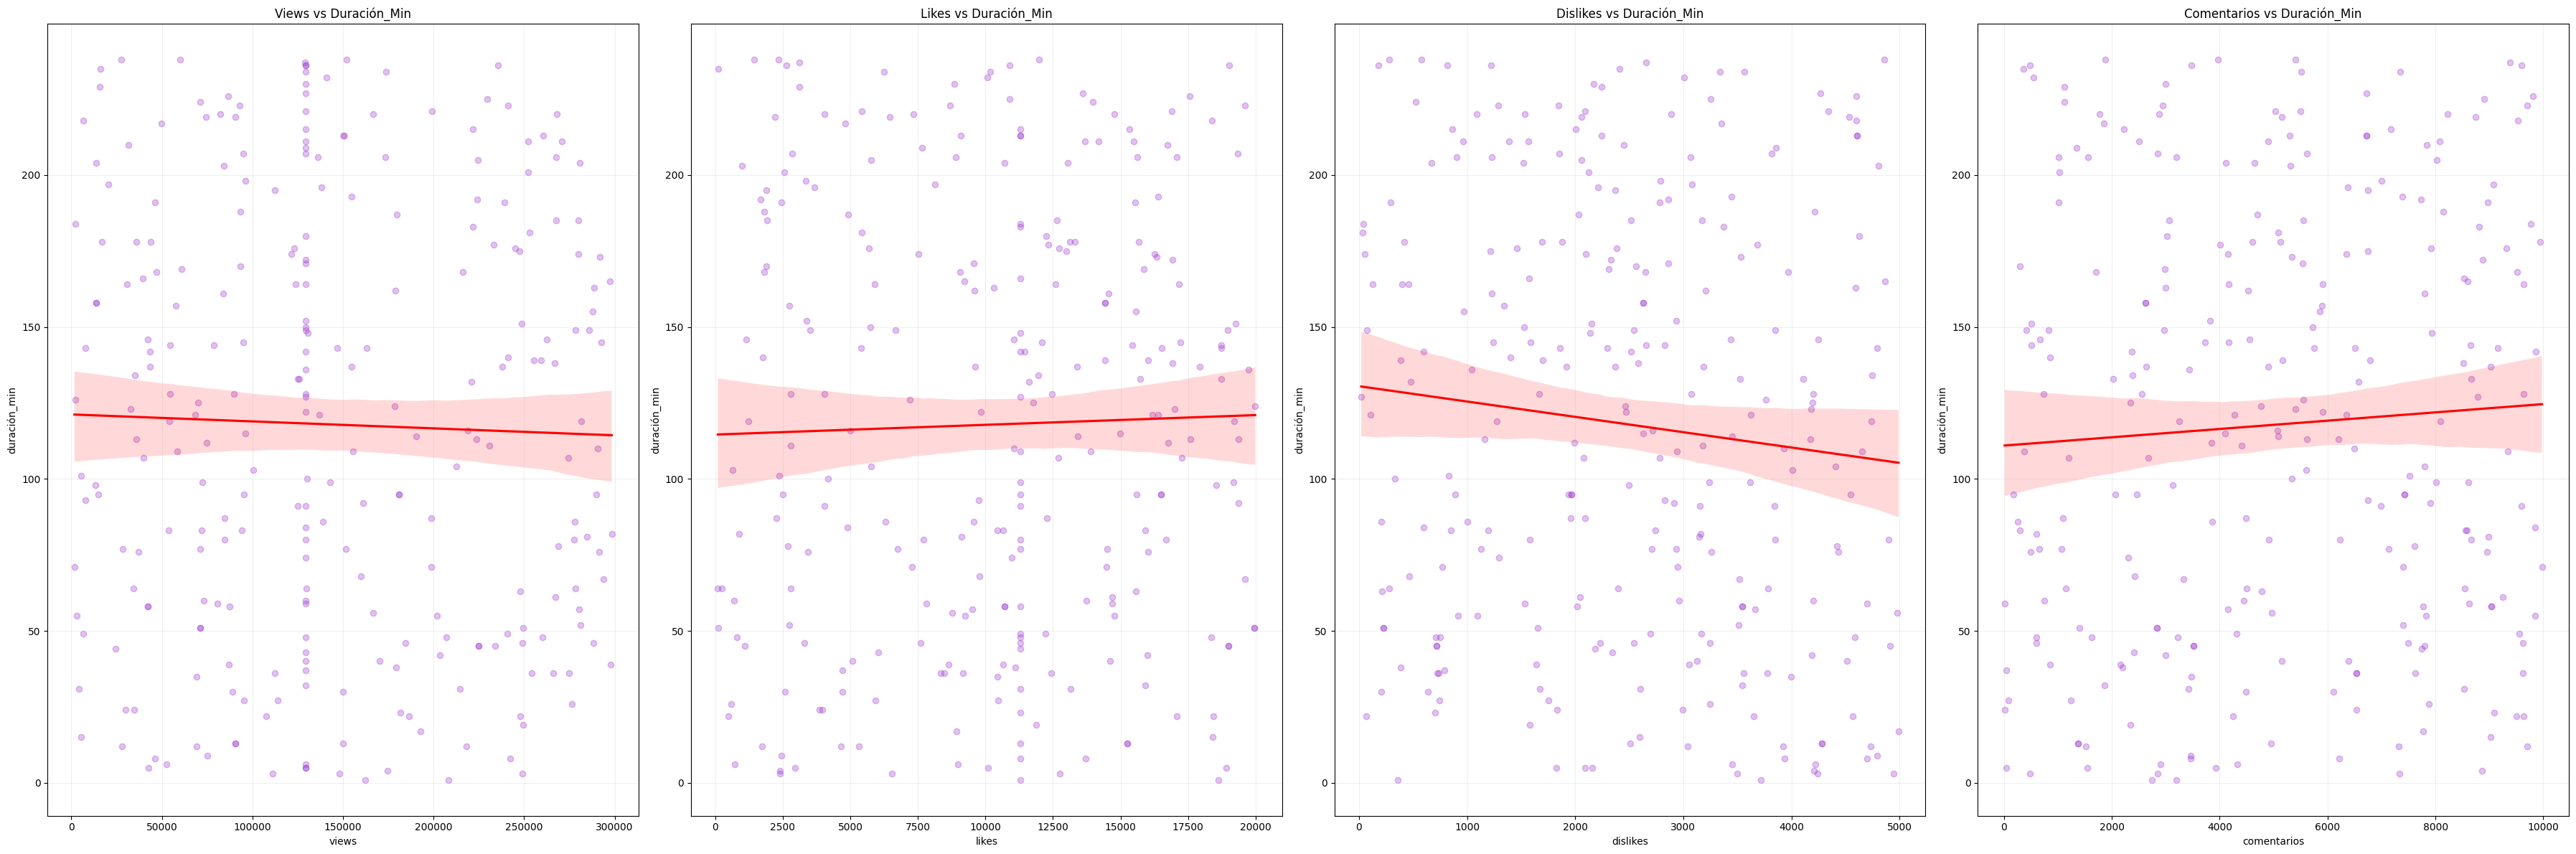

In [ ]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por

comparaciones = [
    ('views', 'duración_min'),
    ('likes', 'duración_min'),
    ('dislikes', 'duración_min'),
    ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

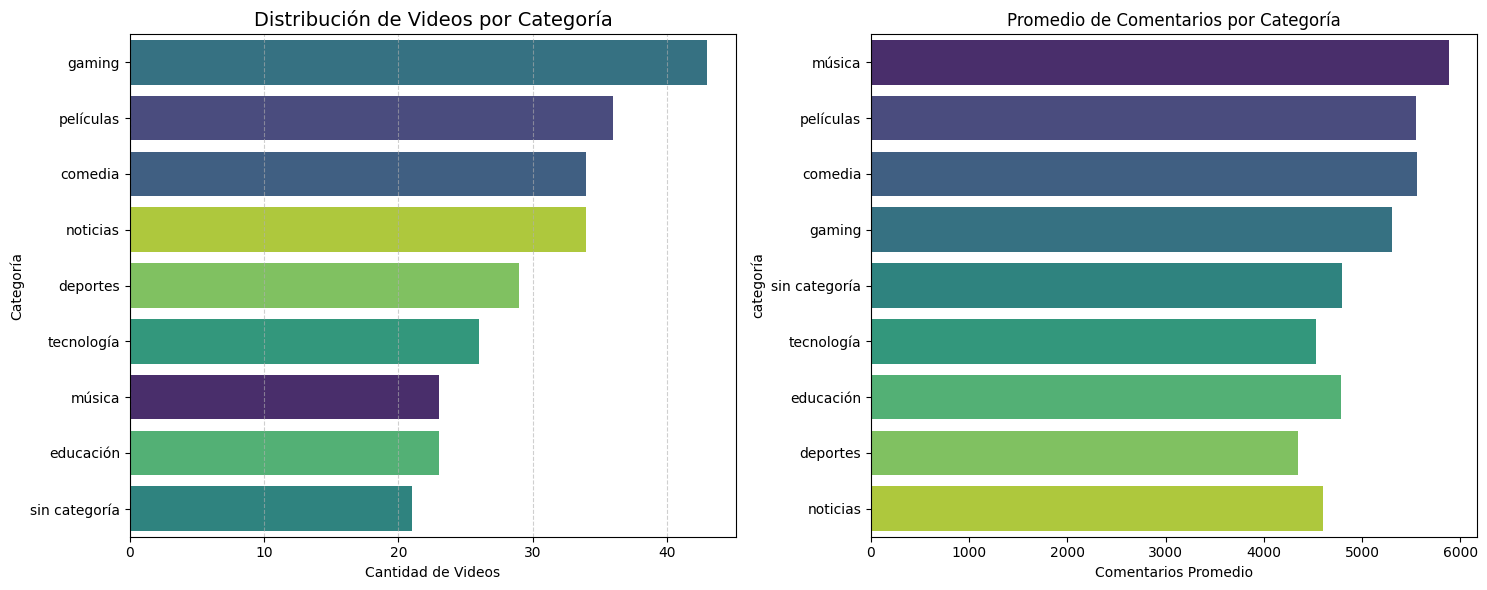

In [ ]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

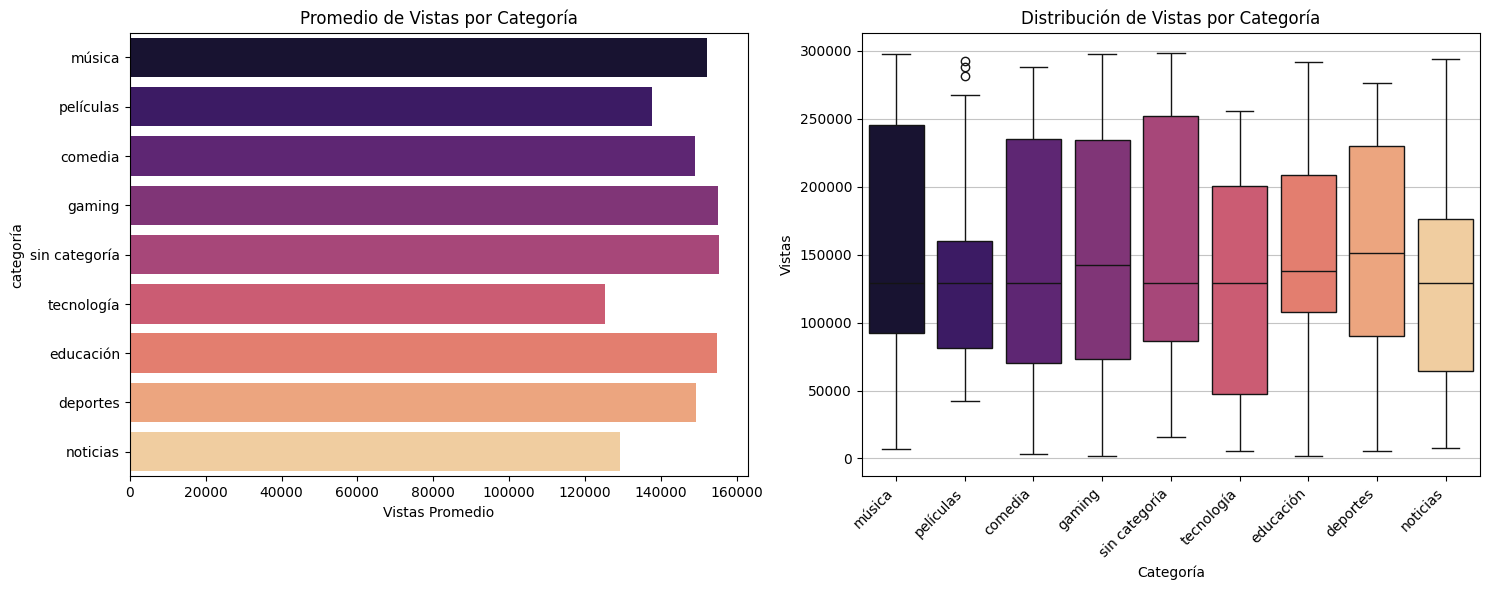

In [ ]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [ ]:
# Definir variables para la agrupación

categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_copy['agrupacion_cat'] = df_copy['categoría'].apply(categoria)
pie_data = df_copy['agrupacion_cat'].value_counts()

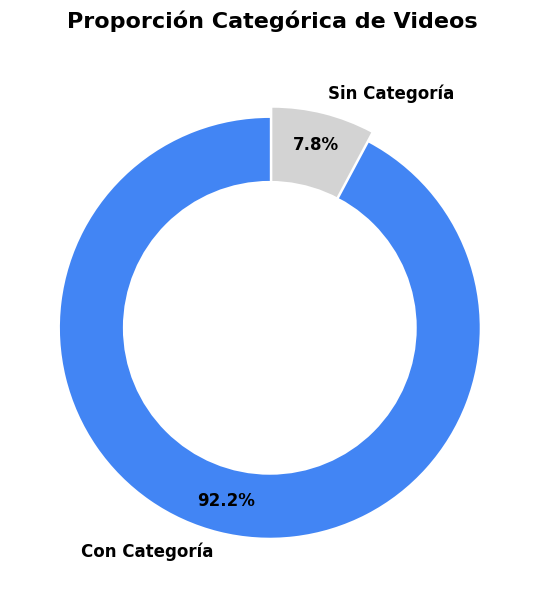

In [ ]:
# Realizar gráfico de dona

colors_pie = ['#4285F4', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [ ]:
# Definir variables

df_filtrado = df_copy[df_copy['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

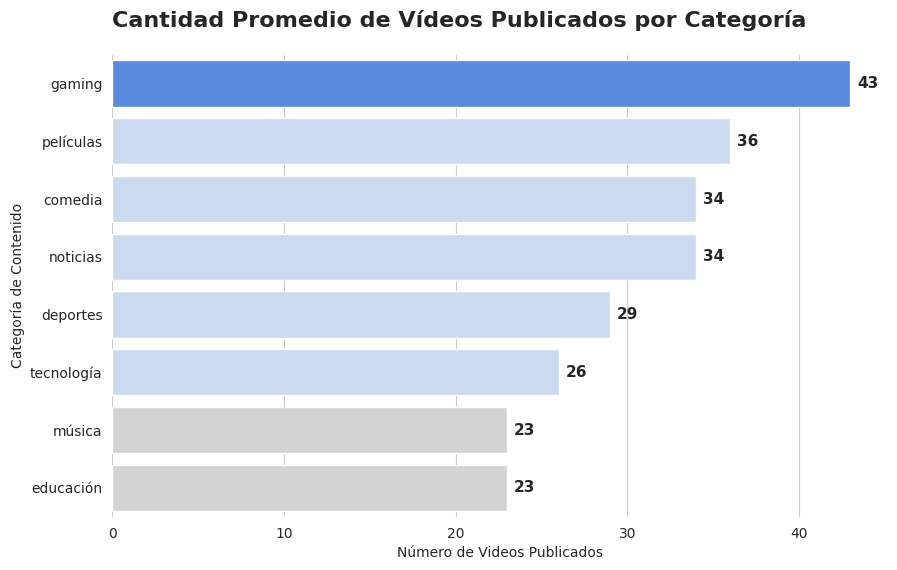

In [ ]:
# Realizar gráfico de barras

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [ ]:
# Definir variables

vistas_mean = df_copy.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

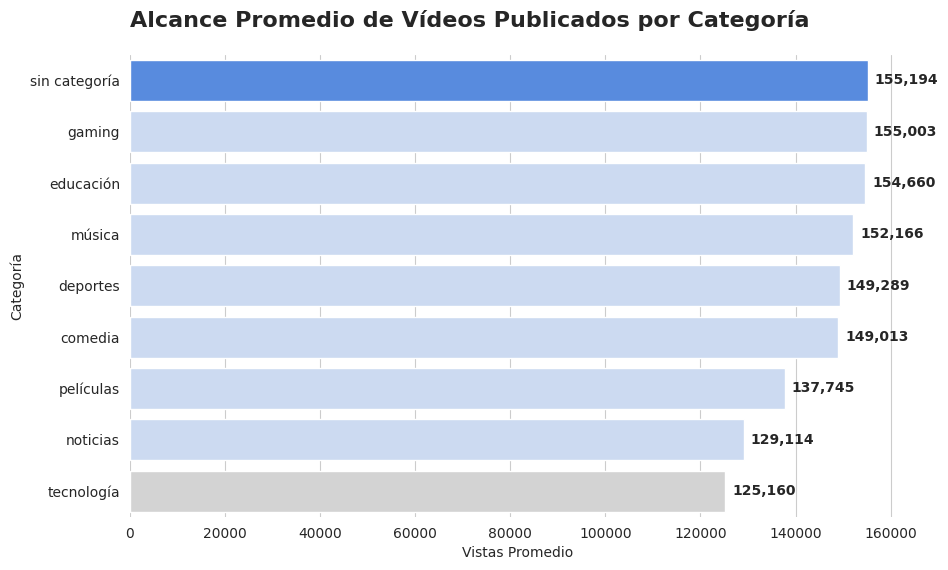

In [ ]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [ ]:
# Definir variables


coments_mean = df_copy.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

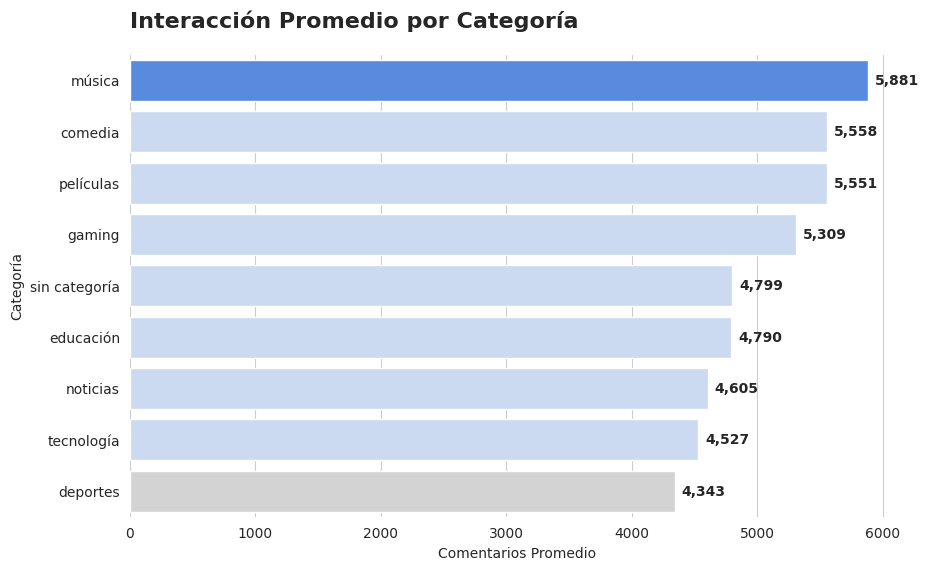

In [ ]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importar datos

df_airnb = pd.read_csv("airbnb_clean.csv")

df_airnb

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.382830,-99.271780,Entire home/apt,3673.0,1,0,Never reviewed,0.00,1,363,0
1,44616,Condesa Haus,196253,Fernando,Cuauhtémoc,19.411620,-99.177940,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1
2,56074,Great space in historical San Rafael,265650,Maris,Cuauhtémoc,19.439770,-99.156050,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,Cuauhtémoc,19.411520,-99.168570,Entire home/apt,1039.0,2,50,2024-10-30,0.30,2,252,1
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,Coyoacán,19.354480,-99.162170,Entire home/apt,1039.0,3,134,2025-08-18,0.81,3,234,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27046,1518356968266486778,Suite Frida,674644167,Heyliana,Venustiano Carranza,19.442240,-99.113440,Private room,1096.0,1,0,Never reviewed,0.00,5,365,0
27047,1518388105556721163,Habitación a un costado de Ciudad Universitaria,222854336,Marco Antonio,Coyoacán,19.308017,-99.168158,Private room,260.0,1,0,Never reviewed,0.00,1,365,0
27048,1518433354720281854,Espacioso departamento en Anzures,470800231,Hector Fernando,Miguel Hidalgo,19.434460,-99.174010,Entire home/apt,996.0,1,0,Never reviewed,0.00,20,365,0
27049,1518462568893975567,Casa Roma Baja 05,710857718,Camila,Cuauhtémoc,19.406435,-99.160934,Entire home/apt,458.0,1,0,Never reviewed,0.00,7,363,0


In [ ]:
# Ver resumen estadístico

columnas_numericas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

df_airnb[columnas_numericas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000
mean,1695.489483,4.580866,53.777679,1.621652,14.559868,232.686333
std,12352.097771,24.784605,85.143043,2.219818,31.892178,122.270858
min,61.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,700.000000,1.000000,4.000000,0.210000,1.000000,140.000000
50%,1039.000000,2.000000,21.000000,1.000000,3.000000,269.000000
75%,1484.000000,2.000000,69.000000,2.370000,11.000000,341.000000
max,900000.000000,1125.000000,1434.000000,119.460000,221.000000,365.000000


**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

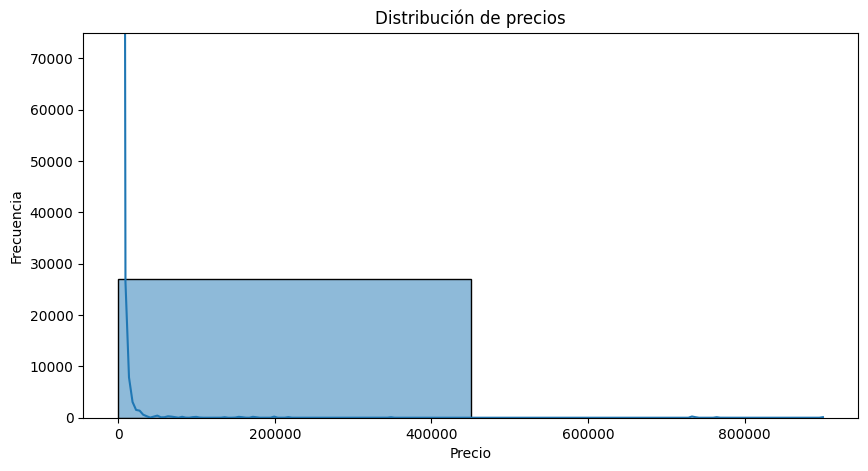

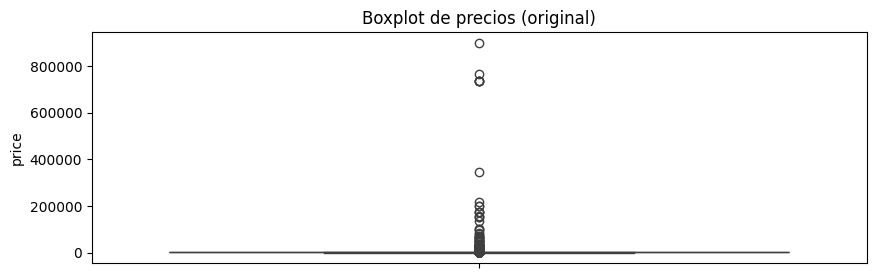

In [ ]:
# Histograma de precios
plt.figure(figsize=(10,5))
sns.histplot(df_airnb['price'], bins=2, kde=True)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.ylim(0,75000)
plt.show()

print()

# Diagrama de caja original
plt.figure(figsize=(10,3))
sns.boxplot(y=df_airnb['price'])
plt.title('Boxplot de precios (original)')
#plt.ylim(0,10000)
plt.show()

In [ ]:
# Ver cantidad de registros iniciales

n_original = len(df_airnb)

print(f'Registros originales: {n_original}')

Registros originales: 27051


In [ ]:
# Calculo del IQR

Q1 = df_airnb['price'].quantile(0.25)
Q3 = df_airnb['price'].quantile(0.75)
Q2 = df_airnb['price'].quantile(0.5)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Límite inferior: {lim_inf}')
print(f'Límite superior: {lim_sup}')

Q1: 700.0
Q3: 1484.0
IQR: 784.0
Límite inferior: -476.0
Límite superior: 2660.0


In [ ]:
# Ver cantidad y proporción con la cantidad inicial

df_filtrado = df_airnb[(df_airnb['price'] >= lim_inf) &(df_airnb['price'] <= lim_sup)]

n_final = len(df_filtrado)

proporcion = n_final / n_original

print(f'Registros finales: {n_final}')
print(f'Proporción conservada: {proporcion:.2%}')

Registros finales: 24741
Proporción conservada: 91.46%


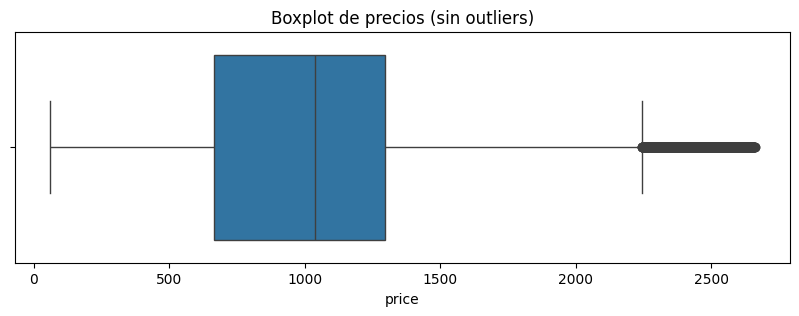

In [ ]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(10,3))
sns.boxplot(x=df_filtrado['price'])
plt.title('Boxplot de precios (sin outliers)')
plt.show()

**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

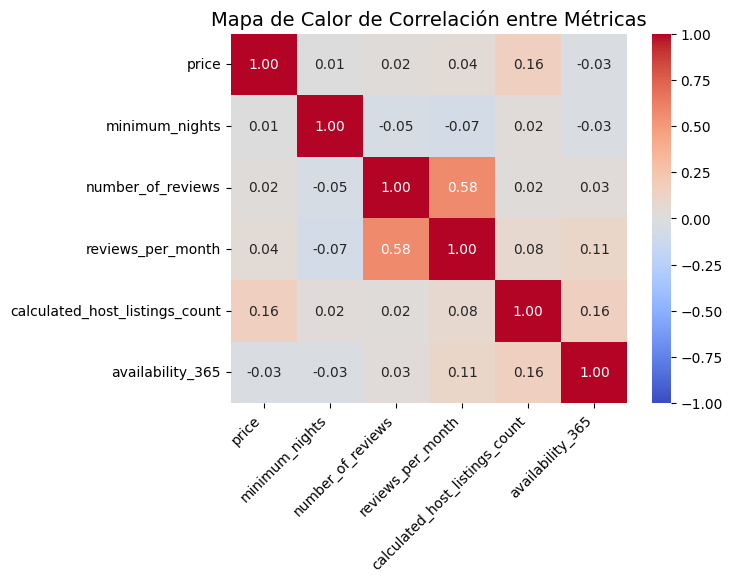

In [ ]:
# Realizar matriz de correlación

corr_matrix = df_filtrado[columnas_numericas].corr()

sns.heatmap(corr_matrix, cmap = 'coolwarm', annot= True, fmt= ".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

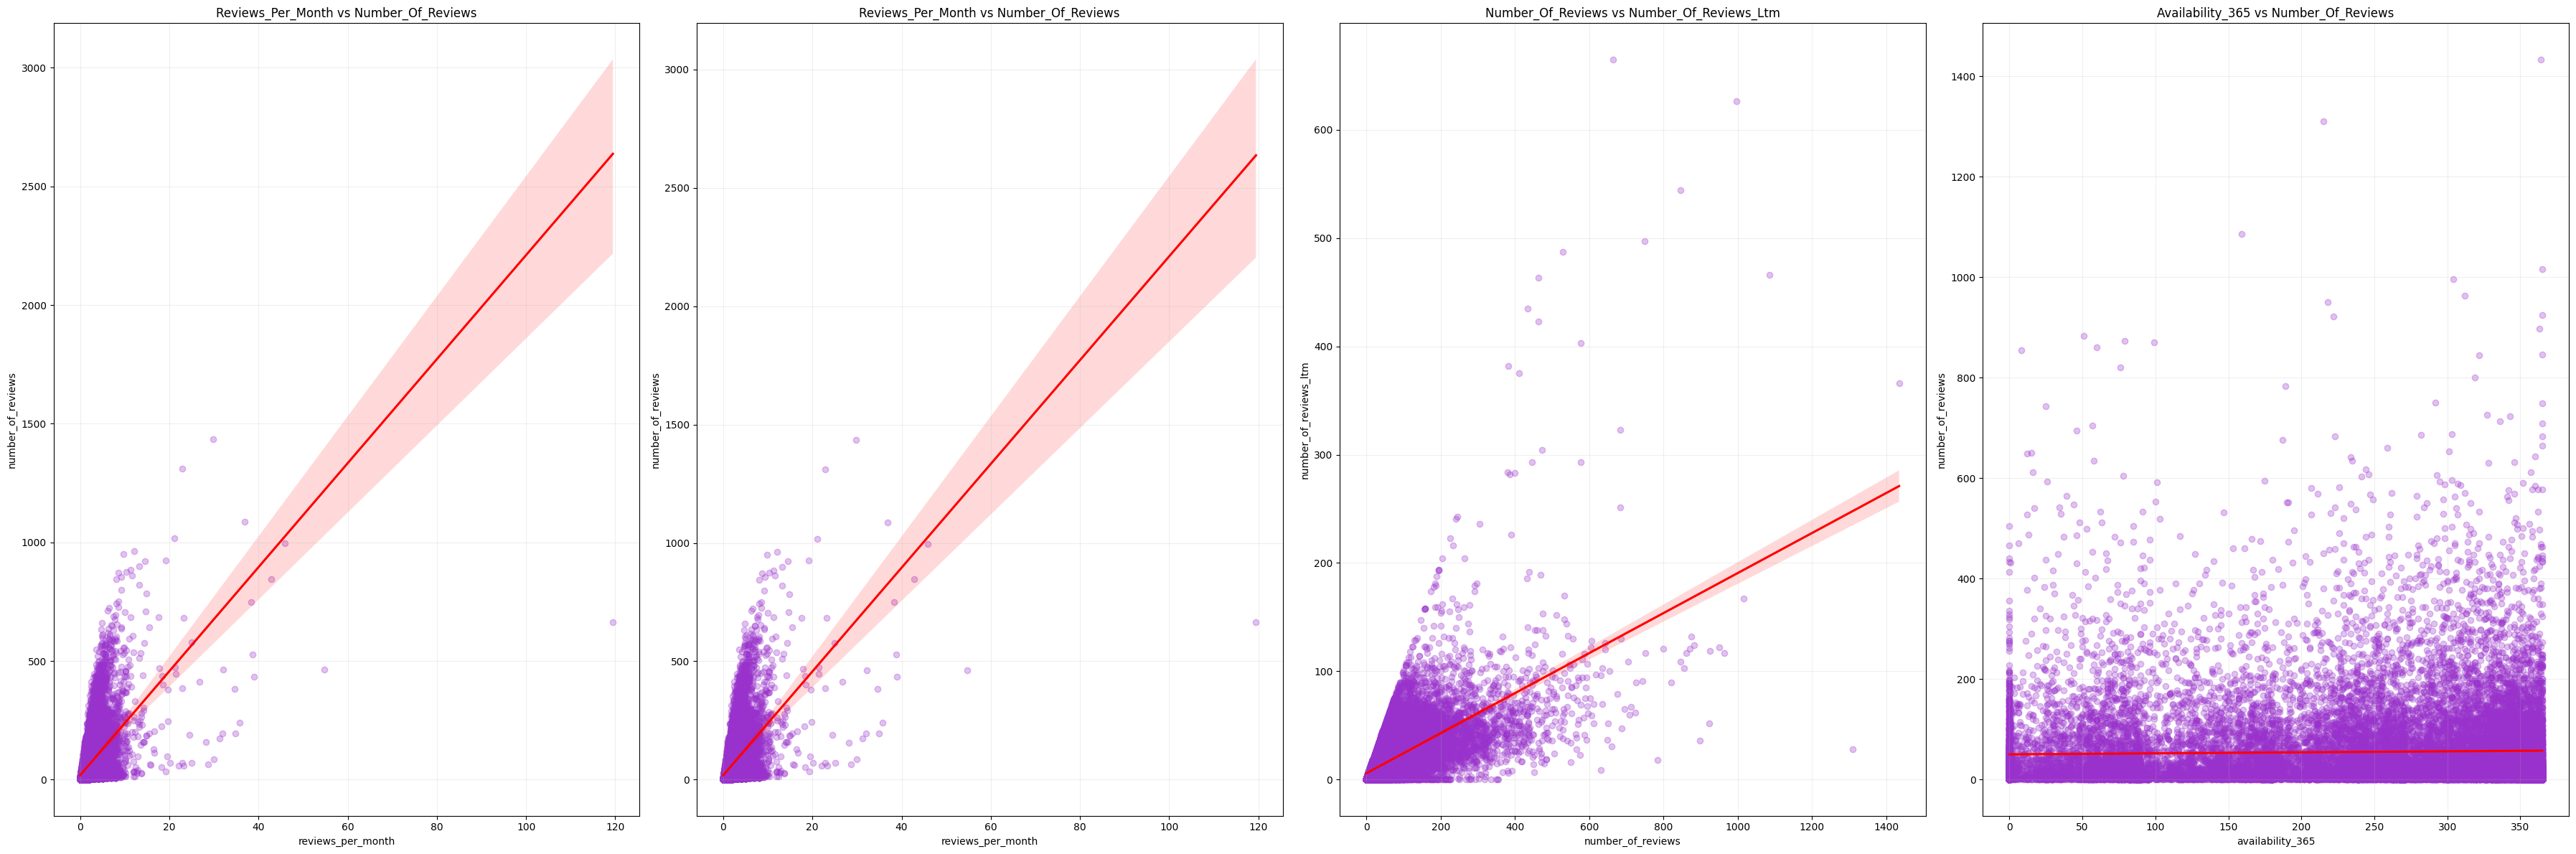

In [ ]:
# Realizar correlaciones divididas

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por

comparaciones = [
    ('reviews_per_month', 'number_of_reviews'),
    ('reviews_per_month', 'number_of_reviews'),
    ('number_of_reviews', 'number_of_reviews_ltm'),
    ('availability_365', 'number_of_reviews')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_filtrado, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [ ]:
# Cálculo de la regresión lineal simple

x = df_filtrado['reviews_per_month']
y = df_filtrado['number_of_reviews_ltm']

beta, alpha = np.polyfit(x, y, 1)

print(f'y = {beta:.2f}x + {alpha:.2f}')


y = 9.06x + 1.01


In [ ]:
#otra manera

x_mean = np.mean(x)
y_mean = np.mean(x)

b1 = np.sum((x-x_mean)*(y-y_mean)) / np.sum((x-x_mean)**2)

b0 = y_mean - b1*x_mean

print(f"Intercepto (b0): {b0}")
print(f"Pendiente (b1): {b1}")

Intercepto (b0): -13.377200250172729
Pendiente (b1): 9.057428251903152


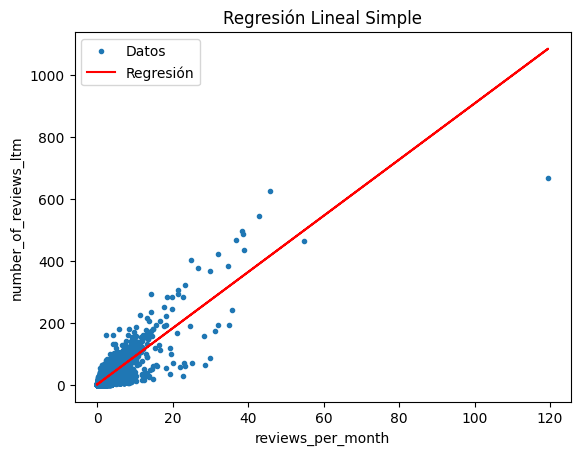

In [ ]:
plt.plot(x,y, 'o', label= 'Datos', ms=3)
plt.plot(x, beta*x + alpha, color= 'red', label= 'Regresión' )
plt.xlabel('reviews_per_month')
plt.ylabel('number_of_reviews_ltm')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.show()

In [ ]:
# Calculo del descenso de gradiente

m = 0
b = 0

lr = 0.01
epochs = 1000

n = len(x)

losses = []

for epoch in range(epochs):

    y_pred = m*x + b

    error = y_pred - y

    loss = np.mean(error**2)
    losses.append(loss)

    dm = (2/n) * np.sum(error*x)
    db = (2/n) * np.sum(error)

    m = m - lr*dm
    b = b - lr*db

print(f"y = {m:.4f}x + {b:.4f}")

y = 9.0574x + 1.0101


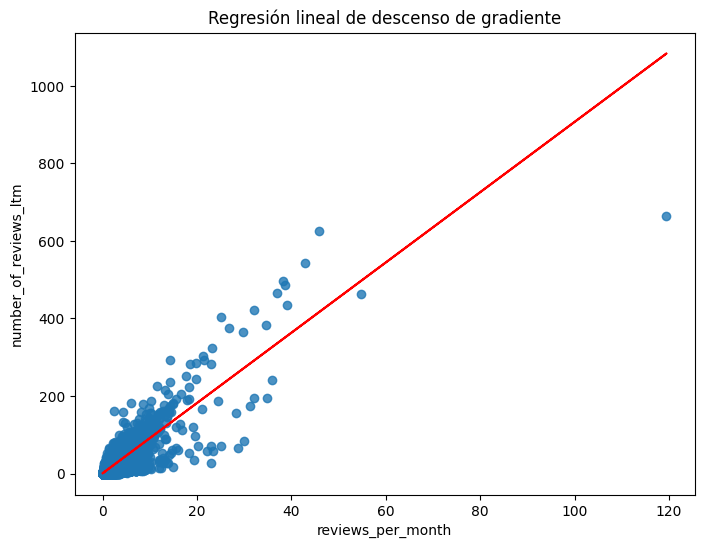

In [ ]:
# Visualizar regresión lineal y perdidas

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.8)

#x = np.linspace(x.min(), x.max(), 100)
y_line = m*x + b

plt.plot(x, y_line, color='red')

plt.xlabel('reviews_per_month')
plt.ylabel('number_of_reviews_ltm')
plt.title('Regresión lineal de descenso de gradiente')

plt.show()

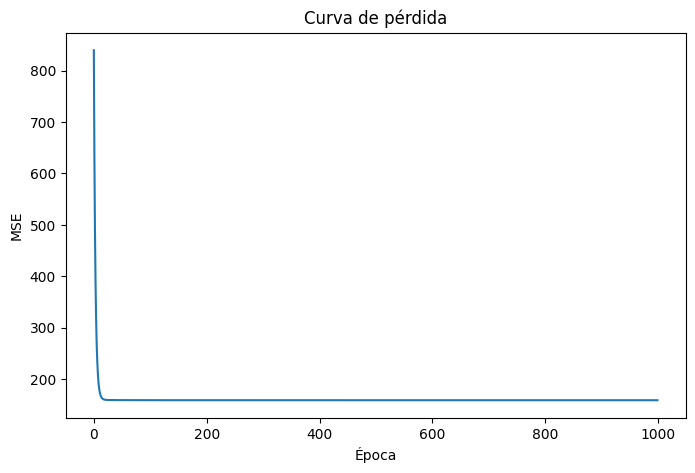

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Curva de pérdida')

plt.show()

In [ ]:
# Registro final de perdida

error_inicial = losses[0]
error_final = losses[-1]

reduccion = error_inicial - error_final

reduccion_pct = (reduccion / error_inicial) * 100

In [ ]:
print(f'Error inicial: {error_inicial:.4f}')
print(f'Error final: {error_final:.4f}')
print(f'Reducción absoluta: {reduccion:.4f}')
print(f'Reducción porcentual: {reduccion_pct:.2f}%')

Error inicial: 839.4546
Error final: 159.4647
Reducción absoluta: 679.9899
Reducción porcentual: 81.00%


**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

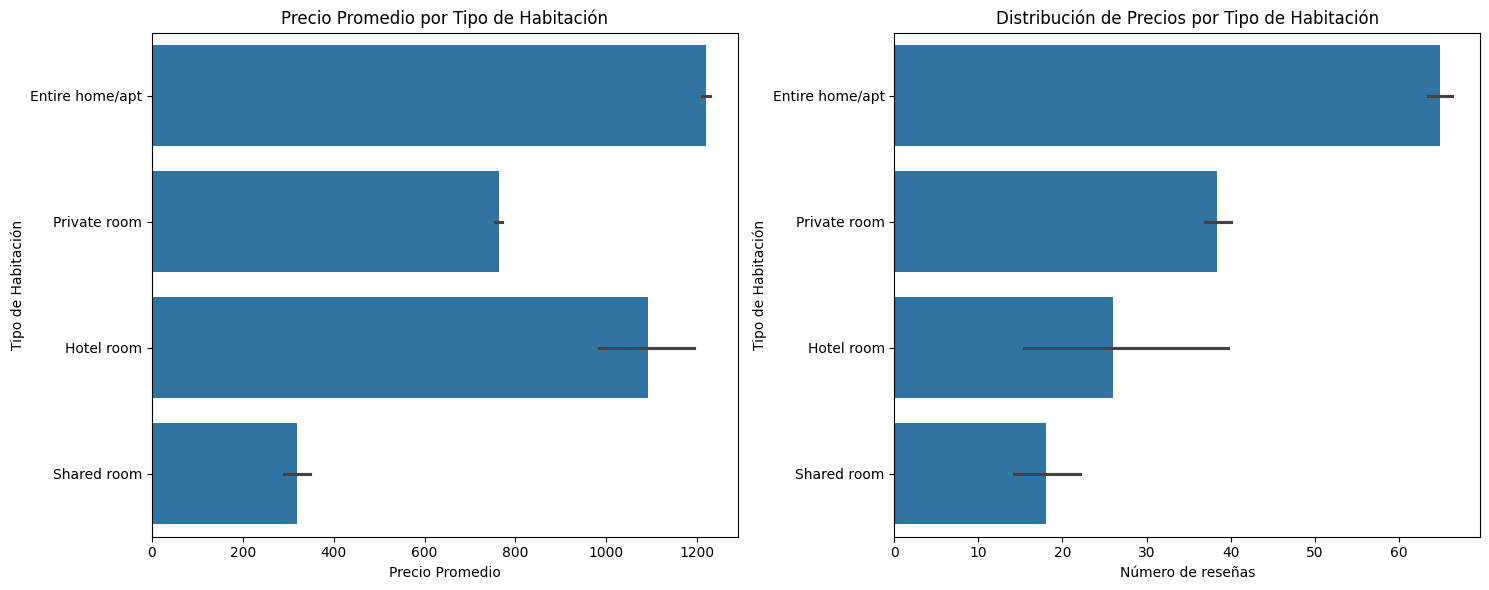

In [ ]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_filtrado, x='price', y='room_type')
plt.title('Precio Promedio por Tipo de Habitación')
plt.xlabel('Precio Promedio')
plt.ylabel('Tipo de Habitación')


plt.subplot(1, 2, 2)
sns.barplot(data=df_filtrado, x='number_of_reviews', y='room_type')
plt.title('Distribución de Precios por Tipo de Habitación')
plt.xlabel('Número de reseñas')
plt.ylabel('Tipo de Habitación')

plt.tight_layout()
plt.show()

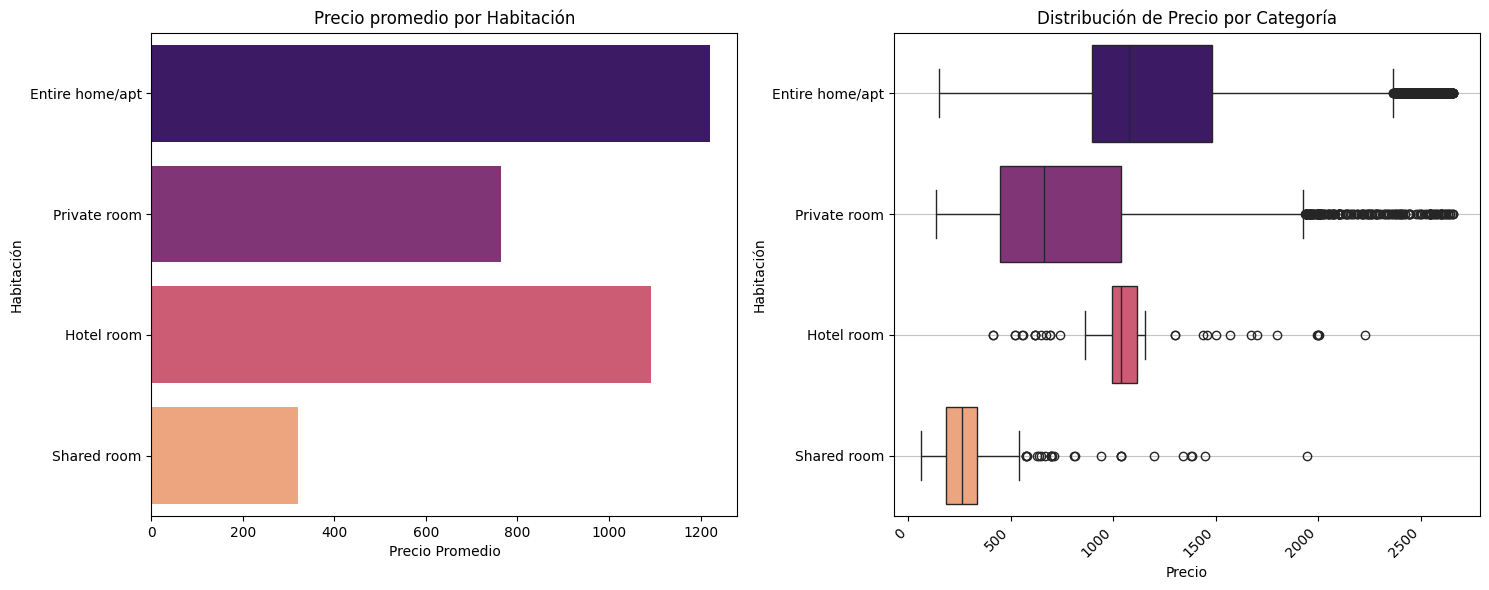

In [ ]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_filtrado, x="price", y= 'room_type',
            estimator='mean', palette='magma', errorbar=None, hue='room_type')
plt.title('Precio promedio por Habitación')
plt.xlabel('Precio Promedio')
plt.ylabel('Habitación')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_filtrado, x='price', y='room_type', palette='magma', hue='room_type')
plt.title('Distribución de Precio por Categoría')
plt.xlabel('Precio')
plt.ylabel('Habitación')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [ ]:
# Definir variables para la agrupación

conteo_room = df_filtrado['room_type'].value_counts()

categorias = conteo_room.index
conteos = conteo_room.values

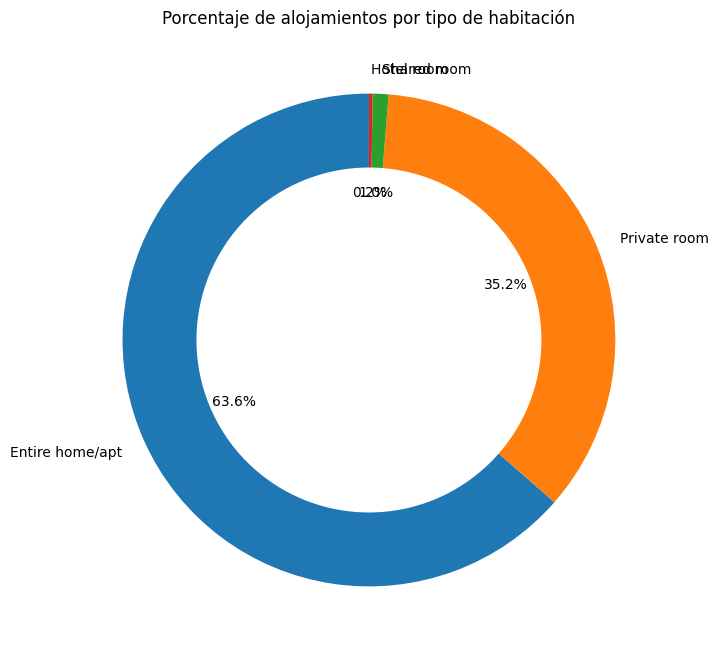

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    conteos,
    labels=categorias,
    autopct='%1.1f%%',
    startangle=90,
)

# Crear agujero central
centro = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centro)

plt.title('Porcentaje de alojamientos por tipo de habitación')

plt.show()

**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

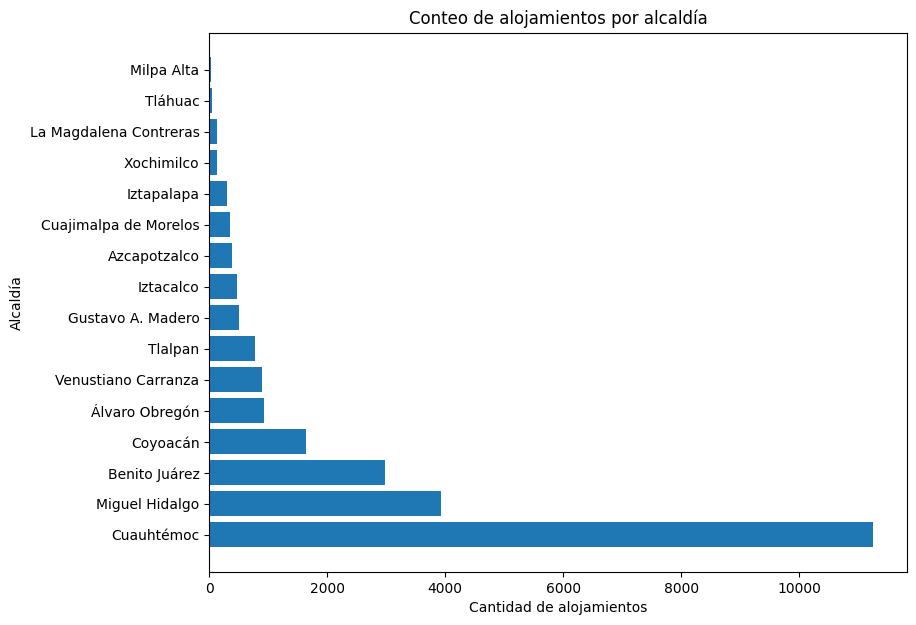

In [ ]:
# Realizar gráfico de barras

conteo_alcaldia = (
    df_filtrado['neighbourhood']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,7))

plt.barh(
    conteo_alcaldia.index,
    conteo_alcaldia.values
)

plt.title('Conteo de alojamientos por alcaldía')
plt.xlabel('Cantidad de alojamientos')
plt.ylabel('Alcaldía')

plt.show()

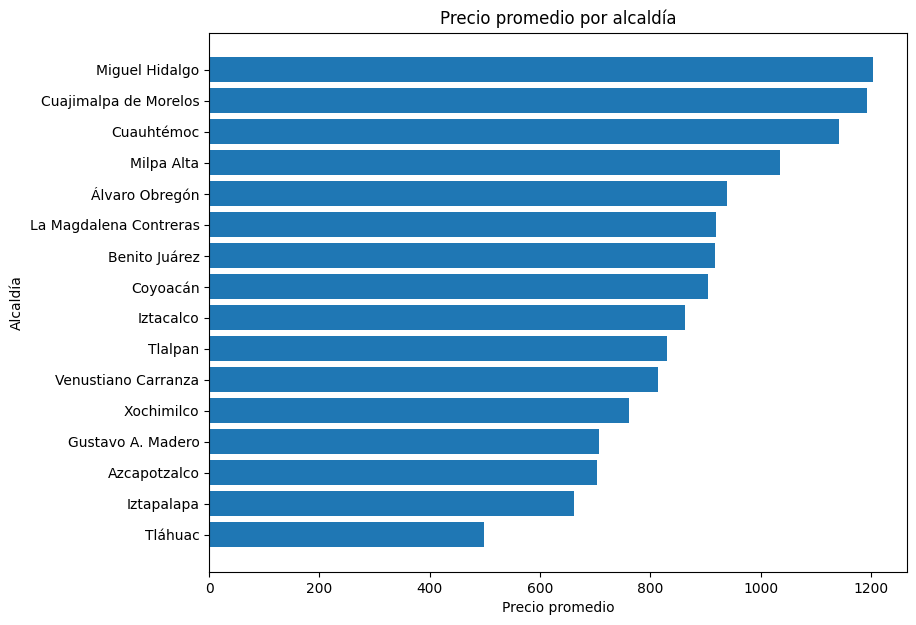

In [ ]:
# Realizar gráfico de barras

precio_promedio = (
    df_filtrado
    .groupby('neighbourhood')['price']
    .mean()
    .sort_values()
)

plt.figure(figsize=(9,7))

plt.barh(
    precio_promedio.index,
    precio_promedio.values
)

plt.title('Precio promedio por alcaldía')
plt.xlabel('Precio promedio')
plt.ylabel('Alcaldía')

plt.show()

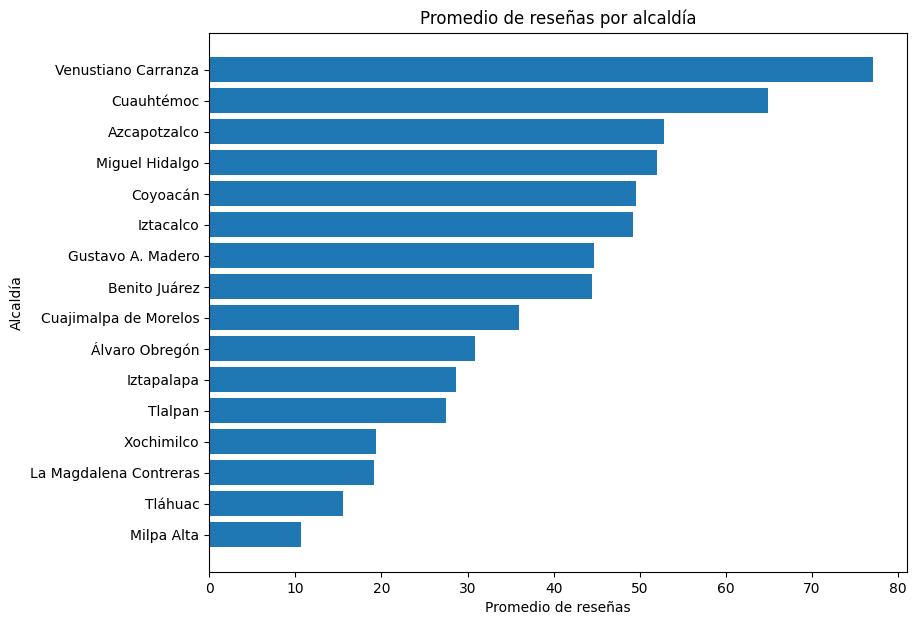

In [ ]:
# Realizar gráfico de barras

reseñas_promedio = (
    df_filtrado
    .groupby('neighbourhood')['number_of_reviews']
    .mean()
    .sort_values()
)

plt.figure(figsize=(9,7))

plt.barh(
    reseñas_promedio.index,
    reseñas_promedio.values
)

plt.title('Promedio de reseñas por alcaldía')
plt.xlabel('Promedio de reseñas')
plt.ylabel('Alcaldía')

plt.show()